In [1]:
import cv2
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix, ConfusionMatrixDisplay
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from skimage import feature
import pickle
import os

In [2]:
LIMIT = 1300
IMG_SIZE = (300, 300)
LABELS = np.array(['Blast', 'Brownspot', 'Healthy'])

In [3]:
# Load data
def load_images_from_directory(base_path, limit=1000):
    data = []
    labels = []
    for folder_name in LABELS:
        folder_path = os.path.join(base_path, folder_name)
        if not os.path.exists(folder_path):
            print(f"Directory not found: {folder_path}")
            continue
        
        print(len(os.listdir(folder_path)), "images in", folder_name)
        for i, filename in enumerate(os.listdir(folder_path)):
            if i == limit: break
            image_path = os.path.join(folder_path, filename)
            img = cv2.imread(image_path)
            if img is None:
                print(f"Failed to load image: {image_path}")
                continue

            data.append(cv2.resize(img, IMG_SIZE))
            labels.append(folder_name)
        print(f"Loaded {len(data)} images from {folder_name}")
    
    return np.array(data), np.array(labels)


In [4]:
test_dataset, labels = load_images_from_directory('datasets/Rice Diseases Image Dataset', LIMIT)

123 images in Blast
Loaded 123 images from Blast
123 images in Brownspot
Loaded 246 images from Brownspot
123 images in Healthy
Loaded 369 images from Healthy


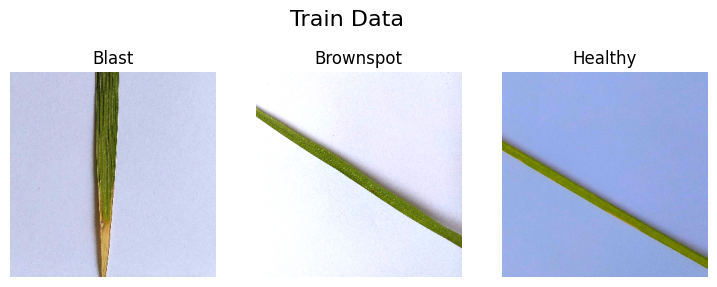

In [27]:
fig = plt.figure(figsize=(9, 6))

fig.suptitle('Train Data', fontsize=16)

for j in range(len(LABELS)):
    fig.add_subplot(2, len(LABELS), j+1)
    index = np.where(labels == LABELS[j])[0][0]
    plt.imshow(cv2.cvtColor(test_dataset[index], cv2.COLOR_BGR2RGB))
    plt.axis('off') 
    plt.title(LABELS[j])

In [11]:
def calculate_texture_features_n_hog(image):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    glcm = feature.graycomatrix(gray, distances=[1], angles=[0], symmetric=True, normed=True)
    contrast = feature.graycoprops(glcm, 'contrast')
    energy = feature.graycoprops(glcm, 'energy')
    homogeneity = feature.graycoprops(glcm, 'homogeneity')
    correlation = feature.graycoprops(glcm, 'correlation')
    dissimilarity = feature.graycoprops(glcm, 'dissimilarity')
    
    # lbp = feature.local_binary_pattern(gray, P=8, R=1, method='uniform')
    hog = feature.hog(gray, pixels_per_cell=(16, 16), cells_per_block=(1, 1), visualize=False, feature_vector=True)
    # return np.concatenate((lbp.flatten(), hog))
    # return hog
    return np.concatenate((hog,contrast.flatten(), energy.flatten(), homogeneity.flatten(), correlation.flatten(), dissimilarity.flatten()))

In [12]:
def calculate_histogram(image, channels, mask=None, histSize=[256], ranges=[0, 256]):
    result = []
    for i in range(len(channels)):
        hist = cv2.calcHist([image], [i], mask, histSize, ranges)
        cv2.normalize(hist, hist)
        hist.flatten()
        result.append(hist)
    return np.array(result).flatten()

In [13]:
def extract_features(images):
    features = []
    for img in images:
        color_hist = calculate_histogram(img, channels=[0, 1, 2])
        # color_moments = calculate_color_moments(img)
        hu_moments = cv2.HuMoments(cv2.moments(cv2.cvtColor(img, cv2.COLOR_BGR2GRAY))).flatten()
        texture_features_n_hog = calculate_texture_features_n_hog(img)
        # feature_vector = np.concatenate((color_hist, color_moments, texture_features_n_hog))
        # feature_vector = np.concatenate((color_hist, color_moments, hu_moments))
        feature_vector = np.concatenate((color_hist, hu_moments, texture_features_n_hog))
        features.append(feature_vector)
    return np.array(features)

In [14]:
feature_img1 = extract_features([test_dataset[0]])
print(feature_img1.shape)

(1, 3696)


In [15]:
test_dataset_features = extract_features(test_dataset)

In [16]:
# Load the model from disk
with open('svm_1.pkl', 'rb') as file:
  loaded_classifier = pickle.load(file) 

# Use the loaded model to make predictions on new data
with open('scaler_1.pkl', 'rb') as file:
  loaded_scaler = pickle.load(file) 

x_test_normal = loaded_scaler.transform(test_dataset_features)
predictions = loaded_classifier.predict(x_test_normal)

In [17]:
# Evaluate the model
accuracy = accuracy_score(labels, predictions)
print(f"Accuracy: {accuracy * 100:.4f}%")
precision, recall, fscore, average = precision_recall_fscore_support(labels, predictions, average='weighted')
print(f"Precission: {precision * 100:.4f}%")
print(f"Recall: {recall * 100:.4f}%")
print(f"F1: {fscore * 100:.4f}%")

Accuracy: 33.6043%
Precission: 44.4746%
Recall: 33.6043%
F1: 17.2382%


c:\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [25]:
print(predictions[50:150])
print(labels[50:150])

print(predictions.shape, labels.shape)

['Healthy' 'Healthy' 'Healthy' 'Healthy' 'Healthy' 'Healthy' 'Healthy'
 'Healthy' 'Healthy' 'Healthy' 'Healthy' 'Healthy' 'Healthy' 'Healthy'
 'Healthy' 'Healthy' 'Healthy' 'Healthy' 'Healthy' 'Healthy' 'Healthy'
 'Healthy' 'Healthy' 'Healthy' 'Healthy' 'Healthy' 'Healthy' 'Healthy'
 'Healthy' 'Healthy' 'Healthy' 'Healthy' 'Healthy' 'Healthy' 'Healthy'
 'Healthy' 'Healthy' 'Healthy' 'Healthy' 'Healthy' 'Healthy' 'Healthy'
 'Healthy' 'Healthy' 'Healthy' 'Healthy' 'Healthy' 'Healthy' 'Healthy'
 'Healthy' 'Healthy' 'Healthy' 'Healthy' 'Healthy' 'Healthy' 'Healthy'
 'Healthy' 'Healthy' 'Healthy' 'Healthy' 'Healthy' 'Healthy' 'Healthy'
 'Healthy' 'Healthy' 'Healthy' 'Healthy' 'Healthy' 'Healthy' 'Healthy'
 'Healthy' 'Healthy' 'Healthy' 'Healthy' 'Healthy' 'Healthy' 'Healthy'
 'Healthy' 'Healthy' 'Healthy' 'Healthy' 'Healthy' 'Healthy' 'Healthy'
 'Healthy' 'Healthy' 'Healthy' 'Healthy' 'Healthy' 'Healthy' 'Healthy'
 'Healthy' 'Healthy' 'Healthy' 'Healthy' 'Healthy' 'Healthy' 'Healthy'
 'Heal

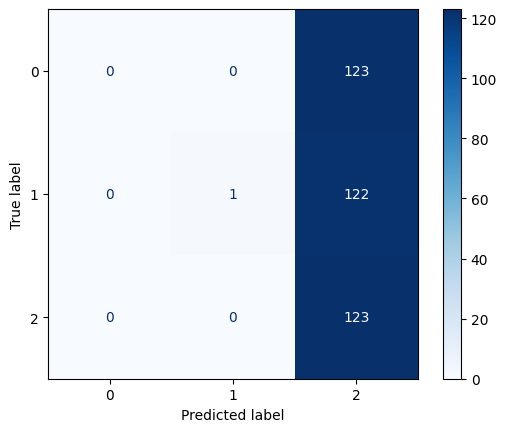

In [ ]:
cm = confusion_matrix(labels, predictions)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.show()